In [121]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [122]:
import zipfile
import pandas as pd
import glob
import numpy as np
import warnings
from pathlib import Path
import csv
import matplotlib.pyplot as plt
import re

### Import chEMBL data for all viruses

In [123]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')

In [102]:
allVirusData_chEMBL = pd.read_csv(modelBuildingDataDir + 'AllVirusData_chEMBL_combined.csv')
allVirusData_chEMBL

,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,standard_relation,...,hbd,rotatable_bonds,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus
0,CHEMBL93655,COC(=O)c1c(C)[nH]c(C)c1C(=O)c1ccccc1Cc1ccccc1,NaN,NaN,NaN,347.41,NaN,-0.02,%,'=',...,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
1,CHEMBL4303665,C/C(=C(\CCOP(=O)(O)O)SC(=O)c1ccccc1)N(C=O)Cc1c...,NaN,NaN,NaN,466.46,NaN,-0.17,%,'=',...,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
2,CHEMBL492574,CN[C@@H]1[C@@H](O[C@H]2O[C@H](CO)[C@@H](N)[C@H...,NaN,NaN,NaN,539.58,NaN,0.22,%,'=',...,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
3,CHEMBL441,CCCC(C)C1(CC)C(=O)NC(=S)NC1=O,NaN,NaN,NaN,242.34,NaN,0.09,%,'=',...,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
4,CHEMBL1423437,COc1ccc(/C=C(/C#N)c2cccnc2)cc1OC,NaN,NaN,NaN,266.30,NaN,0.09,%,'=',...,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43100,CHEMBL1631739,CCC(Sc1nc2ccsc2c(=O)n1Cc1ccc2c(c1)OCO2)C(=O)NC...,C23H21N3O5S2,IXNBENOPJYMMQU-UHFFFAOYSA-N,InChI=1S/C23H21N3O5S2/c1-2-19(21(27)24-11-15-4...,483.57,Small molecule,41.00,%,'=',...,1.0,8.0,0.30,33.0,4.0,0.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta
43101,CHEMBL1631743,O=C(CSc1nc2nccnc2c(=O)n1Cc1cccs1)NCCc1ccccc1,C21H19N5O2S2,KAXCHLAOBYVWBT-UHFFFAOYSA-N,InChI=1S/C21H19N5O2S2/c27-17(22-9-8-15-5-2-1-3...,437.55,Small molecule,6.00,%,'=',...,1.0,8.0,0.34,30.0,4.0,0.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta
43102,CHEMBL1632515,Cc1cc(C)cc(-n2c(=O)c3sccc3n(CC(=O)N3CCN(c4cccc...,C26H26N4O3S,VAAJVHVMOKTAQL-UHFFFAOYSA-N,InChI=1S/C26H26N4O3S/c1-18-14-19(2)16-21(15-18...,474.59,Small molecule,2.20,%,'=',...,0.0,4.0,0.46,34.0,4.0,0.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta
43103,CHEMBL1632518,O=C(Cn1c(=O)n(Cc2ccco2)c(=O)c2sc3ccccc3c21)NCc...,C24H18ClN3O4S,RJTMADKPFKESDQ-UHFFFAOYSA-N,InChI=1S/C24H18ClN3O4S/c25-16-9-7-15(8-10-16)1...,479.95,Small molecule,0.00,%,'=',...,1.0,6.0,0.40,33.0,5.0,0.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta


### Count Standard Type

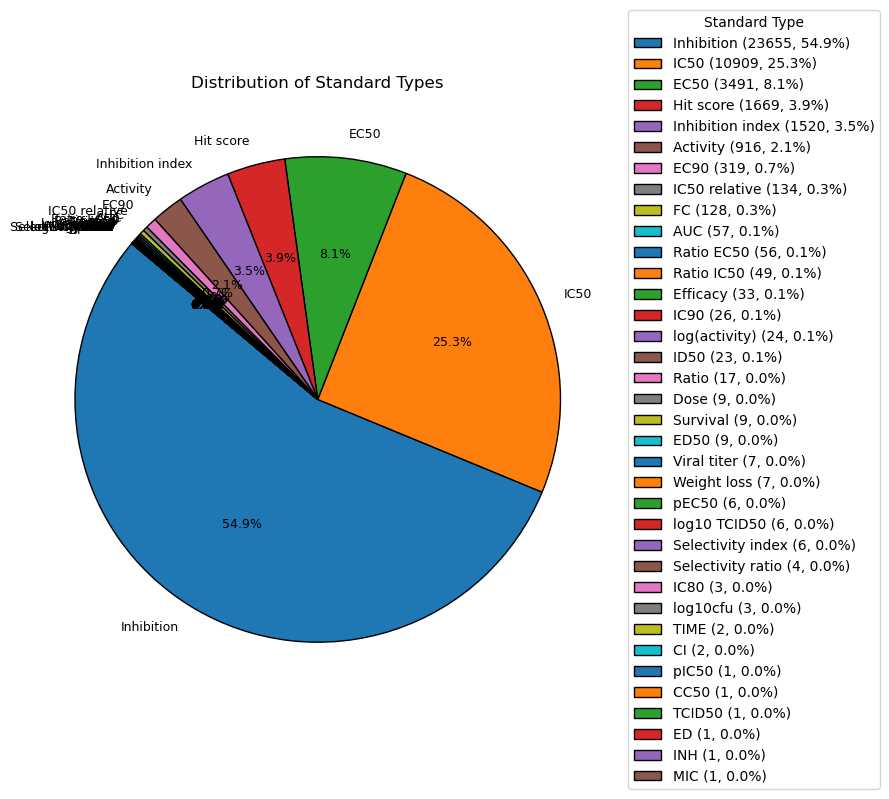

In [103]:
# Count occurrences of each Standard Type
type_counts = allVirusData_chEMBL["standard_type"].value_counts()
total = type_counts.sum()

# Legend labels with counts and percentages
legend_labels = [
    f"{stype} ({count}, {count/total:.1%})"
    for stype, count in type_counts.items()
]

# Plot pie chart with inside labels showing just Standard Type
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    type_counts,
    labels=type_counts.index,  # short labels inside slices
    autopct='%1.1f%%',         # show % inside too
    startangle=140,
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontsize': 9}
)

# Legend with full details
plt.legend(
    wedges,
    legend_labels,
    title="Standard Type",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title("Distribution of Standard Types")
plt.tight_layout()
plt.show()

In [104]:
# Count and sort standard_type values
typeCounts = allVirusData_chEMBL["standard_type"].value_counts(dropna=True)
total = typeCounts.sum()

print("Standard Types sorted by frequency:\n")
for stype, count in typeCounts.items():
    pct = (count / total) * 100
    print(f"{stype:30s} : {count:6d}  ({pct:5.2f}%)")

Standard Types sorted by frequency:

Inhibition                     :  23655  (54.88%)
IC50                           :  10909  (25.31%)
EC50                           :   3491  ( 8.10%)
Hit score                      :   1669  ( 3.87%)
Inhibition index               :   1520  ( 3.53%)
Activity                       :    916  ( 2.13%)
EC90                           :    319  ( 0.74%)
IC50 relative                  :    134  ( 0.31%)
FC                             :    128  ( 0.30%)
AUC                            :     57  ( 0.13%)
Ratio EC50                     :     56  ( 0.13%)
Ratio IC50                     :     49  ( 0.11%)
Efficacy                       :     33  ( 0.08%)
IC90                           :     26  ( 0.06%)
log(activity)                  :     24  ( 0.06%)
ID50                           :     23  ( 0.05%)
Ratio                          :     17  ( 0.04%)
Dose                           :      9  ( 0.02%)
Survival                       :      9  ( 0.02%)
ED50         

### Understanding Standard Types in Bioactivity Data

In antiviral drug design, **Standard Types** represent the biological readouts measured in assays.  
They indicate how effective and safe a compound is against a virus:

- **IC50 / IC90 / IC80** → Concentration that inhibits 50%, 90%, or 80% of viral activity (potency).  
- **EC50 / EC90** → Concentration that achieves 50% or 90% of the desired effect in cells (cell-based efficacy).  
- **ED50 / ED** → Dose at which 50% of test animals show the desired effect (in vivo efficacy).  
- **Activity / Inhibition** → General measures of viral suppression or % inhibition at fixed dose.  
- **Selectivity Index (SI)** → Safety margin = toxic dose / effective dose.  
- **Survival** → % survival in treated vs untreated groups (animal/clinical studies).  
- **Fold Change (FC), Ratio IC50/EC50** → Resistance or comparative potency metrics.  
- **Log(activity), log10CFU** → Log-scaled activity or viral load measures.  

In short: 
- For early drug discovery: IC50/EC50 are the most critical.
- For translation to animals/clinics: ED50, Selectivity Index, and Survival become essential.
- For resistance studies: Ratio IC50/EC50 matters.

### Converts all standard types (IC50/EC50/IC90/EC90) to µM

In [105]:
# 1) Which standard types are convertible?
# Convertible (by definition concentration endpoints): ICxx / ECxx (e.g., IC50, EC90, IC80, EC99, etc.)
# Also convertible if present: Ki, Kd (binding constants—concentrations)
CONC_TYPE_PATTERNS = [
    r'\b[IE]C\s*\d+\b',   # IC50, EC90, etc. (spaces tolerated)
    r'\bK[di]\b',         # Ki or Kd
]

# Units we can convert to µM
UNIT_TO_uM = {
    "M": 1e6,
    "mM": 1e3,
    "uM": 1.0, "μM": 1.0, "µM": 1.0,
    "nM": 1e-3,
    "pM": 1e-6,
}

def is_conc_type(std_type: str) -> bool:
    if not isinstance(std_type, str):
        return False
    s = std_type.strip()
    s_no_space = s.replace(" ", "")
    return any(re.search(pat, s_no_space, flags=re.IGNORECASE) for pat in CONC_TYPE_PATTERNS)

def to_uM(value, unit):
    if pd.isna(value) or pd.isna(unit):
        return np.nan
    factor = UNIT_TO_uM.get(str(unit).strip())
    if factor is None:
        return np.nan
    try:
        return float(value) * factor
    except Exception:
        return np.nan

# 2) Copy the original DataFrame
allVirusData_chEMBL_uM = allVirusData_chEMBL.copy()   

# 3) Add conversion flags and the µM column
allVirusData_chEMBL_uM["is_conc_type"] = allVirusData_chEMBL_uM["standard_type"].apply(is_conc_type)
allVirusData_chEMBL_uM["has_known_unit"] = allVirusData_chEMBL_uM["standard_units"].isin(UNIT_TO_uM.keys())
allVirusData_chEMBL_uM["is_numeric_value"] = pd.to_numeric(allVirusData_chEMBL_uM["standard_value"], errors="coerce").notna()

# Convertible if: concentration-type AND known unit AND numeric value
allVirusData_chEMBL_uM["is_convertible_to_uM"] = (
    allVirusData_chEMBL_uM["is_conc_type"] &
    allVirusData_chEMBL_uM["has_known_unit"] &
    allVirusData_chEMBL_uM["is_numeric_value"]
)

# Compute µM values where convertible; else NaN
allVirusData_chEMBL_uM["value_uM"] = np.where(
    allVirusData_chEMBL_uM["is_convertible_to_uM"],
    [to_uM(v, u) for v, u in zip(allVirusData_chEMBL_uM["standard_value"], allVirusData_chEMBL_uM["standard_units"])],
    np.nan
)

# Quick summary
print("Convertible standards:", int(allVirusData_chEMBL_uM["is_convertible_to_uM"].sum()))
print("Non-convertible standards:", int((~allVirusData_chEMBL_uM["is_convertible_to_uM"]).sum()))

columns_to_drop = [
        'is_conc_type', 
        'has_known_unit', 
        'is_numeric_value', 
        'is_convertible_to_uM'
    ]
    
# Drop the columns, using errors='ignore' to avoid a KeyError if a column doesn't exist
allVirusData_chEMBL_uM = allVirusData_chEMBL_uM.drop(columns=columns_to_drop, errors='ignore')
allVirusData_chEMBL_uM

Convertible standards: 14522
Non-convertible standards: 28583


,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,standard_relation,...,rotatable_bonds,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus,value_uM
0,CHEMBL93655,COC(=O)c1c(C)[nH]c(C)c1C(=O)c1ccccc1Cc1ccccc1,NaN,NaN,NaN,347.41,NaN,-0.02,%,'=',...,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2,NaN
1,CHEMBL4303665,C/C(=C(\CCOP(=O)(O)O)SC(=O)c1ccccc1)N(C=O)Cc1c...,NaN,NaN,NaN,466.46,NaN,-0.17,%,'=',...,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2,NaN
2,CHEMBL492574,CN[C@@H]1[C@@H](O[C@H]2O[C@H](CO)[C@@H](N)[C@H...,NaN,NaN,NaN,539.58,NaN,0.22,%,'=',...,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2,NaN
3,CHEMBL441,CCCC(C)C1(CC)C(=O)NC(=S)NC1=O,NaN,NaN,NaN,242.34,NaN,0.09,%,'=',...,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2,NaN
4,CHEMBL1423437,COc1ccc(/C=C(/C#N)c2cccnc2)cc1OC,NaN,NaN,NaN,266.30,NaN,0.09,%,'=',...,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43100,CHEMBL1631739,CCC(Sc1nc2ccsc2c(=O)n1Cc1ccc2c(c1)OCO2)C(=O)NC...,C23H21N3O5S2,IXNBENOPJYMMQU-UHFFFAOYSA-N,InChI=1S/C23H21N3O5S2/c1-2-19(21(27)24-11-15-4...,483.57,Small molecule,41.00,%,'=',...,8.0,0.30,33.0,4.0,0.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta,NaN
43101,CHEMBL1631743,O=C(CSc1nc2nccnc2c(=O)n1Cc1cccs1)NCCc1ccccc1,C21H19N5O2S2,KAXCHLAOBYVWBT-UHFFFAOYSA-N,InChI=1S/C21H19N5O2S2/c27-17(22-9-8-15-5-2-1-3...,437.55,Small molecule,6.00,%,'=',...,8.0,0.34,30.0,4.0,0.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta,NaN
43102,CHEMBL1632515,Cc1cc(C)cc(-n2c(=O)c3sccc3n(CC(=O)N3CCN(c4cccc...,C26H26N4O3S,VAAJVHVMOKTAQL-UHFFFAOYSA-N,InChI=1S/C26H26N4O3S/c1-18-14-19(2)16-21(15-18...,474.59,Small molecule,2.20,%,'=',...,4.0,0.46,34.0,4.0,0.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta,NaN
43103,CHEMBL1632518,O=C(Cn1c(=O)n(Cc2ccco2)c(=O)c2sc3ccccc3c21)NCc...,C24H18ClN3O4S,RJTMADKPFKESDQ-UHFFFAOYSA-N,InChI=1S/C24H18ClN3O4S/c25-16-9-7-15(8-10-16)1...,479.95,Small molecule,0.00,%,'=',...,6.0,0.40,33.0,5.0,0.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta,NaN


### Keep only those rows which have Convertible standards

In [106]:
allVirusData_chEMBL_uM = allVirusData_chEMBL_uM.dropna(subset=['value_uM'])
allVirusData_chEMBL_uM

,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,standard_relation,...,rotatable_bonds,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus,value_uM
182,CHEMBL5087131,CC(C)C[C@H](NCc1ccc(-c2ccccc2)cc1)C(=O)N[C@@H]...,NaN,NaN,NaN,538.74,NaN,4000.0,nM,'>',...,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2,4.0000
183,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,NaN,NaN,NaN,602.59,NaN,10.0,nM,'=',...,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2,0.0100
305,CHEMBL4852507,C=CCn1ccc2c(C(=O)Oc3cncc(Cl)c3)cccc21,NaN,NaN,NaN,312.76,NaN,15000.0,nM,'=',...,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2,15.0000
307,CHEMBL4846056,CC(C)(C)OC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CN1CC...,NaN,NaN,NaN,431.62,NaN,10050.0,nM,'=',...,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2,10.0500
308,CHEMBL5419985,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@@H]2CC...,NaN,NaN,NaN,499.53,NaN,64.0,nM,'=',...,NaN,NaN,NaN,NaN,NaN,CHEMBL4303835,SARS-CoV-2,Severe acute respiratory syndrome coronavirus 2,SARS-CoV-2,0.0640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42946,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,C19H33NO2,DGQVWCKBMRUAMQ-VDZJLULYSA-N,"InChI=1S/C19H33NO2/c1-18(2)15-9-10-19(3,14-15)...",307.48,NaN,4600.0,nM,'=',...,5.0,0.72,22.0,0.0,0.0,CHEMBL4296577,Marburgvirus,Marburgvirus,Marburg,4.6000
42947,CHEMBL5584026,CN1CCN(CC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)C3)CC1,C17H30N2O2,WLBVLQYBHQQYFP-JLJPHGGASA-N,"InChI=1S/C17H30N2O2/c1-16(2)13-5-6-17(3,11-13)...",294.44,NaN,25000.0,nM,'=',...,3.0,0.75,21.0,0.0,0.0,CHEMBL4296577,Marburgvirus,Marburgvirus,Marburg,25.0000
42959,CHEMBL1631748,O=c1c(/C=N/Cc2ccco2)c(CSc2ccc(Cl)cc2)[nH]n1-c1...,C23H17ClN4O2S2,MCVUVXZGPCCVIY-DHRITJCHSA-N,InChI=1S/C23H17ClN4O2S2/c24-15-7-9-17(10-8-15)...,481.00,Small molecule,1.3,nM,'=',...,7.0,0.23,32.0,5.0,1.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta,0.0013
43028,CHEMBL1630982,O=C(NCc1ccc2c(c1)OCO2)C(Cc1ccccc1)NS(=O)(=O)c1...,C26H23N3O5S,RBKAYBAQPXQFML-UHFFFAOYSA-N,InChI=1S/C26H23N3O5S/c30-26(28-16-19-11-12-22-...,489.55,Small molecule,1.6,nM,'=',...,8.0,0.39,35.0,4.0,0.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta,0.0016


### Add p-scale (pPotency) conversion to bring all concentrations (µM) onto a logarithmic scale

In [47]:
dfp = allVirusData_chEMBL_uM.copy()  # your frame with `value_uM`

# 1) Make sure value_uM is numeric
dfp["value_uM"] = pd.to_numeric(dfp.get("value_uM"), errors="coerce")

# 2) Normalize the relation column (handles "'", spaces, synonyms, unicode)
def normalize_relation(rel):
    if pd.isna(rel):
        return None
    s = str(rel).strip()

    # remove surrounding quotes if present
    if (s.startswith("'") and s.endswith("'")) or (s.startswith('"') and s.endswith('"')):
        s = s[1:-1].strip()

    s = s.strip().lower()

    # map HTML/unicode and synonyms
    s = s.replace("&lt;", "<").replace("&gt;", ">")
    s = s.replace("≤", "<=").replace("≥", ">=")
    s = s.replace("==", "=")

    # word synonyms
    if s in {"eq", "equals", "equal"}:
        s = "="
    elif s in {"lt", "less", "lessthan"}:
        s = "<"
    elif s in {"le", "lessequal", "lessthanorequal"}:
        s = "<="
    elif s in {"gt", "greater", "greaterthan"}:
        s = ">"
    elif s in {"ge", "greaterequal", "greaterthanorequal"}:
        s = ">="
    elif s in {"approx", "~", "≈"}:
        s = "="

    # keep only one of: =, <, >, <=, >= ; else None
    if s in {"=", "<", ">", "<=", ">="}:
        return s
    return None

dfp["relation_norm"] = dfp.get("standard_relation").apply(normalize_relation)

# 3) Safe log10
def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = x > 0
    out[mask] = np.log10(x[mask])
    return out

# 4) Compute pPotency (p = 6 - log10(µM))
p_from_uM = 6.0 - safe_log10(dfp["value_uM"])

# exact if relation is '=' or missing
has_exact = (dfp["relation_norm"].isna()) | (dfp["relation_norm"].eq('='))

# lower/upper bounds for censored values
is_lt  = dfp["relation_norm"].eq('<')
is_le  = dfp["relation_norm"].eq('<=')
is_gt  = dfp["relation_norm"].eq('>')
is_ge  = dfp["relation_norm"].eq('>=')

dfp["pPotency"]       = np.where(has_exact, p_from_uM, np.nan)
dfp["pPotencyLower"]  = np.where(is_lt | is_le, p_from_uM, np.nan)  # true conc < / ≤ value → pPotency > bound
dfp["pPotencyUpper"]  = np.where(is_gt | is_ge, p_from_uM, np.nan)  # true conc > / ≥ value → pPotency < bound
dfp["pPotencyMid"]    = dfp[["pPotency", "pPotencyLower", "pPotencyUpper"]].median(axis=1, skipna=True)

# 5) Summary
n_exact = int(dfp["pPotency"].notna().sum())
n_lower = int(dfp["pPotencyLower"].notna().sum())
n_upper = int(dfp["pPotencyUpper"].notna().sum())
print(f"Exact pPotency rows: {n_exact}")
print(f"Censored lower-bound rows (relation '<' or '<='): {n_lower}")
print(f"Censored upper-bound rows (relation '>' or '>='): {n_upper}")

# Replace the working frame if you want
allVirusData_chEMBL_uM = dfp
allVirusData_chEMBL_uM

Exact pPotency rows: 1180
Censored lower-bound rows (relation '<' or '<='): 24
Censored upper-bound rows (relation '>' or '>='): 164


,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,standard_relation,...,Target ChEMBL ID,Target Name,Target Organism,Virus,value_uM,relation_norm,pPotency,pPotencyLower,pPotencyUpper,pPotencyMid
4,CHEMBL2016757,N#C[C@@]1(c2ccc3c(N)ncnn23)O[C@H](CO)[C@@H](O)...,C12H13N5O4,BRDWIEOJOWJCLU-LTGWCKQJSA-N,InChI=1S/C12H13N5O4/c13-4-12(10(20)9(19)7(3-18...,291.27,Small molecule,2120.0,nM,'=',...,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah,2.1200,=,5.673664,NaN,NaN,5.673664
5,CHEMBL5205032,CCC(CC)OC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](...,C26H33N6O8P,QHEKHVFPDPTSKM-PZPGFRDGSA-N,InChI=1S/C26H33N6O8P/c1-4-17(5-2)38-25(35)16(3...,588.56,NaN,32.0,nM,'=',...,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah,0.0320,=,7.494850,NaN,NaN,7.494850
7,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...,602.59,Small molecule,29.0,nM,'=',...,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah,0.0290,=,7.537602,NaN,NaN,7.537602
8,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...,602.59,Small molecule,29.0,nM,'=',...,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah,0.0290,=,7.537602,NaN,NaN,7.537602
10,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...,602.59,Small molecule,29.0,nM,'=',...,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah,0.0290,=,7.537602,NaN,NaN,7.537602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1910,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,C19H33NO2,DGQVWCKBMRUAMQ-VDZJLULYSA-N,"InChI=1S/C19H33NO2/c1-18(2)15-9-10-19(3,14-15)...",307.48,NaN,4600.0,nM,'=',...,CHEMBL4296577,Marburgvirus,Marburgvirus,Marburg,4.6000,=,5.337242,NaN,NaN,5.337242
1911,CHEMBL5584026,CN1CCN(CC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)C3)CC1,C17H30N2O2,WLBVLQYBHQQYFP-JLJPHGGASA-N,"InChI=1S/C17H30N2O2/c1-16(2)13-5-6-17(3,11-13)...",294.44,NaN,25000.0,nM,'=',...,CHEMBL4296577,Marburgvirus,Marburgvirus,Marburg,25.0000,=,4.602060,NaN,NaN,4.602060
1923,CHEMBL1631748,O=c1c(/C=N/Cc2ccco2)c(CSc2ccc(Cl)cc2)[nH]n1-c1...,C23H17ClN4O2S2,MCVUVXZGPCCVIY-DHRITJCHSA-N,InChI=1S/C23H17ClN4O2S2/c24-15-7-9-17(10-8-15)...,481.00,Small molecule,1.3,nM,'=',...,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta,0.0013,=,8.886057,NaN,NaN,8.886057
1992,CHEMBL1630982,O=C(NCc1ccc2c(c1)OCO2)C(Cc1ccccc1)NS(=O)(=O)c1...,C26H23N3O5S,RBKAYBAQPXQFML-UHFFFAOYSA-N,InChI=1S/C26H23N3O5S/c30-26(28-16-19-11-12-22-...,489.55,Small molecule,1.6,nM,'=',...,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta,0.0016,=,8.795880,NaN,NaN,8.795880


### some data cleaning

In [48]:
len(allVirusData_chEMBL_uM.dropna(subset=['pPotencyLower']))

24

In [49]:
len(allVirusData_chEMBL_uM.dropna(subset=['pPotencyUpper']))

164

In [50]:
len(allVirusData_chEMBL_uM.dropna(subset=['pPotency']))

1180

In [51]:
len(allVirusData_chEMBL_uM.dropna(subset=['pPotencyMid']))

1368

In [52]:
allVirusData_chEMBL_uM = allVirusData_chEMBL_uM.drop(columns=['relation_norm','pPotencyLower', 'pPotencyUpper'], errors='ignore')
allVirusData_chEMBL_uM

,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,standard_relation,...,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus,value_uM,pPotency,pPotencyMid
4,CHEMBL2016757,N#C[C@@]1(c2ccc3c(N)ncnn23)O[C@H](CO)[C@@H](O)...,C12H13N5O4,BRDWIEOJOWJCLU-LTGWCKQJSA-N,InChI=1S/C12H13N5O4/c13-4-12(10(20)9(19)7(3-18...,291.27,Small molecule,2120.0,nM,'=',...,21.0,2.0,0.0,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah,2.1200,5.673664,5.673664
5,CHEMBL5205032,CCC(CC)OC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](...,C26H33N6O8P,QHEKHVFPDPTSKM-PZPGFRDGSA-N,InChI=1S/C26H33N6O8P/c1-4-17(5-2)38-25(35)16(3...,588.56,NaN,32.0,nM,'=',...,41.0,3.0,2.0,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah,0.0320,7.494850,7.494850
7,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...,602.59,Small molecule,29.0,nM,'=',...,42.0,3.0,2.0,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah,0.0290,7.537602,7.537602
8,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...,602.59,Small molecule,29.0,nM,'=',...,42.0,3.0,2.0,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah,0.0290,7.537602,7.537602
10,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...,602.59,Small molecule,29.0,nM,'=',...,42.0,3.0,2.0,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah,0.0290,7.537602,7.537602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1910,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,C19H33NO2,DGQVWCKBMRUAMQ-VDZJLULYSA-N,"InChI=1S/C19H33NO2/c1-18(2)15-9-10-19(3,14-15)...",307.48,NaN,4600.0,nM,'=',...,22.0,0.0,0.0,CHEMBL4296577,Marburgvirus,Marburgvirus,Marburg,4.6000,5.337242,5.337242
1911,CHEMBL5584026,CN1CCN(CC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)C3)CC1,C17H30N2O2,WLBVLQYBHQQYFP-JLJPHGGASA-N,"InChI=1S/C17H30N2O2/c1-16(2)13-5-6-17(3,11-13)...",294.44,NaN,25000.0,nM,'=',...,21.0,0.0,0.0,CHEMBL4296577,Marburgvirus,Marburgvirus,Marburg,25.0000,4.602060,4.602060
1923,CHEMBL1631748,O=c1c(/C=N/Cc2ccco2)c(CSc2ccc(Cl)cc2)[nH]n1-c1...,C23H17ClN4O2S2,MCVUVXZGPCCVIY-DHRITJCHSA-N,InChI=1S/C23H17ClN4O2S2/c24-15-7-9-17(10-8-15)...,481.00,Small molecule,1.3,nM,'=',...,32.0,5.0,1.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta,0.0013,8.886057,8.886057
1992,CHEMBL1630982,O=C(NCc1ccc2c(c1)OCO2)C(Cc1ccccc1)NS(=O)(=O)c1...,C26H23N3O5S,RBKAYBAQPXQFML-UHFFFAOYSA-N,InChI=1S/C26H23N3O5S/c30-26(28-16-19-11-12-22-...,489.55,Small molecule,1.6,nM,'=',...,35.0,4.0,0.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta,0.0016,8.795880,8.795880


In [94]:
allVirusData_chEMBL_uM.to_csv(os.path.join(modelBuildingDataDir, "allVirusData_chEMBL_uM.csv"))

# Generate MACAW embeddings from SMILES

In [116]:
from rdkit import Chem
from macaw import MACAW, MACAW_optimus

in_path  = os.path.join(modelBuildingDataDir, "allVirusData_chEMBL_uM.csv")
out_path = os.path.join(modelBuildingDataDir, "allVirusData_chEMBL_uM_wMACAW.csv")

# 1) Load
allVirusData_chEMBL_wMACAW = pd.read_csv(in_path)
if "smiles" not in allVirusData_chEMBL_wMACAW.columns:
    raise ValueError("Column 'smiles' not found in the input CSV.")

# 2) Ensure/compute invalidSmiles
def is_valid_smiles(s):
    if not isinstance(s, str) or not s:
        return False
    try:
        return Chem.MolFromSmiles(s) is not None
    except Exception:
        return False

if "invalidSmiles" not in allVirusData_chEMBL_wMACAW.columns:
    allVirusData_chEMBL_wMACAW["invalidSmiles"] = ~allVirusData_chEMBL_wMACAW["smiles"].astype(str).apply(is_valid_smiles)

# 3) Keep valid SMILES
mask_ok = allVirusData_chEMBL_wMACAW["smiles"].notna() & (~allVirusData_chEMBL_wMACAW["invalidSmiles"].fillna(True))
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.loc[mask_ok].reset_index(drop=True)

# 4) Prepare guidance labels (optional but recommended)
has_p = "pPotency" in allVirusData_chEMBL_wMACAW.columns
if has_p:
    fit_mask   = allVirusData_chEMBL_wMACAW["pPotency"].notna()
    smiles_fit = allVirusData_chEMBL_wMACAW.loc[fit_mask, "smiles"].astype(str).tolist()
    y_fit      = allVirusData_chEMBL_wMACAW.loc[fit_mask, "pPotency"].astype(float).tolist()
else:
    smiles_fit = allVirusData_chEMBL_wMACAW["smiles"].astype(str).tolist()
    y_fit      = None

if len(smiles_fit) < 10:
    raise ValueError("Not enough valid molecules to fit MACAW (need at least ~10).")

# 5) Build and fit embedder
if y_fit is not None:
    mcw = MACAW_optimus(smiles_fit, y_fit, problem="regression", exhaustiveness=2, random_state=42)
    mcw.fit(smiles_fit, Y=y_fit)
else:
    mcw = MACAW_optimus(smiles_fit, None, problem="unsupervised", exhaustiveness=2, random_state=42)
    mcw.fit(smiles_fit)

# 6) Transform all rows
X_all = mcw.transform(allVirusData_chEMBL_wMACAW["smiles"].astype(str).tolist())  # [n_rows, n_components]
macaw_cols = [f"macaw_{i}" for i in range(X_all.shape[1])]
for i, c in enumerate(macaw_cols):
    allVirusData_chEMBL_wMACAW[c] = X_all[:, i]

print("MACAW shape:", X_all.shape)
print("Added columns:", macaw_cols[:5], "...")

# 7) Save augmented dataframe
allVirusData_chEMBL_wMACAW.to_csv(out_path, index=False)
print("Saved with MACAW features →", out_path)

Setting recommended combination: secfp6 & sokal
MACAW shape: (14497, 15)
Added columns: ['macaw_0', 'macaw_1', 'macaw_2', 'macaw_3', 'macaw_4'] ...
Saved with MACAW features → /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/allVirusData_chEMBL_uM_wMACAW.csv


In [117]:
allVirusData_chEMBL_wMACAW.shape

(14497, 45)

In [119]:
allVirusData_chEMBL_wMACAW.columns

Index(['Unnamed: 0', 'molecule_chembl_id', 'smiles', 'molecular_formula',
       'inchi_key', 'inchi', 'molecular_weight', 'type', 'standard_value',
       'standard_units', 'standard_relation', 'standard_type', 'pchembl_value',
       'AlogP', 'polar_surface_area', 'hba', 'hbd', 'rotatable_bonds',
       'qed_weighted', 'heavy_atoms', 'aromatic_rings', 'ro5_violations',
       'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Virus',
       'value_uM', 'pPotency', 'pPotencyMid', 'invalidSmiles', 'macaw_0',
       'macaw_1', 'macaw_2', 'macaw_3', 'macaw_4', 'macaw_5', 'macaw_6',
       'macaw_7', 'macaw_8', 'macaw_9', 'macaw_10', 'macaw_11', 'macaw_12',
       'macaw_13', 'macaw_14'],
      dtype='object')

In [120]:
columns_to_select = [
    'smiles', 'macaw_0', 'macaw_1', 'macaw_2', 'macaw_3', 'macaw_4', 
    'macaw_5', 'macaw_6', 'macaw_7', 'macaw_8', 'macaw_9', 'macaw_10', 
    'macaw_11', 'macaw_12', 'macaw_13', 'macaw_14'
]


new_df = allVirusData_chEMBL_wMACAW[columns_to_select]
new_df

,smiles,macaw_0,macaw_1,macaw_2,macaw_3,macaw_4,macaw_5,macaw_6,macaw_7,macaw_8,macaw_9,macaw_10,macaw_11,macaw_12,macaw_13,macaw_14
0,CC(C)C[C@H](NCc1ccc(-c2ccccc2)cc1)C(=O)N[C@@H]...,0.090482,-0.029242,-0.000223,0.017987,-0.001335,0.004656,0.048688,0.049331,-0.088644,-0.000413,0.023809,-0.037297,-0.020152,0.057207,-0.012111
1,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,-0.125448,0.364455,-0.347631,0.033750,-0.048967,-0.012730,0.009382,0.064876,-0.072066,0.030987,0.000152,0.020210,-0.013467,-0.095941,-0.008255
2,C=CCn1ccc2c(C(=O)Oc3cncc(Cl)c3)cccc21,-0.040166,-0.022879,0.010414,0.019459,-0.038226,0.037658,0.004739,-0.018539,-0.013666,0.002629,0.020102,-0.002572,0.011779,-0.020606,0.010781
3,CC(C)(C)OC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CN1CC...,0.046222,-0.000649,0.000949,0.051934,-0.011894,-0.007679,0.005476,0.014705,0.003768,-0.022021,-0.000161,-0.004709,0.001996,0.024783,0.003542
4,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@@H]2CC...,0.263238,0.011003,-0.067742,-0.326794,-0.032209,0.068252,-0.069007,-0.065328,0.193613,0.082753,-0.038881,0.018661,-0.090660,-0.046533,-0.021243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14492,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,0.032446,0.029979,0.005639,-0.013649,-0.040968,-0.018853,-0.000163,0.011290,0.028803,-0.044172,-0.003003,0.016718,0.011315,0.039435,-0.013675
14493,CN1CCN(CC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)C3)CC1,0.027631,0.022649,0.020786,-0.005598,-0.049608,-0.018942,-0.024243,0.026900,0.034198,-0.038204,-0.019593,0.023574,0.022787,0.025402,-0.032697
14494,O=c1c(/C=N/Cc2ccco2)c(CSc2ccc(Cl)cc2)[nH]n1-c1...,-0.013836,-0.010945,0.017761,0.036225,-0.003416,0.039427,0.011049,-0.033116,-0.007252,0.003833,0.013414,-0.010213,0.014109,-0.022057,-0.000154
14495,O=C(NCc1ccc2c(c1)OCO2)C(Cc1ccccc1)NS(=O)(=O)c1...,-0.026200,-0.049218,0.003270,0.043487,0.006254,0.032360,-0.002391,0.002122,0.002176,-0.007993,0.019308,-0.021324,-0.014410,0.003654,0.000016


# Add new molecular descriptors using RDKit + mordred

In [76]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem.QED import qed
from rdkit.Chem import Crippen, Lipinski, MACCSkeys
from rdkit.Chem import rdFingerprintGenerator as FPgen
from mordred import Calculator, descriptors as mdes

# ---------- config: equivalence map so we don't duplicate what's already in your base DF ----------
RDKit_to_existing = {
    "MW": "molecular_weight",
    "TPSA": "polar_surface_area",
    "AlogP": "AlogP",
    "HBA": "hba",
    "HBD": "hbd",
    "RotBonds": "rotatable_bonds",
    "AromaticRings": "aromatic_rings",
    "HeavyAtoms": "heavy_atoms",
    "QED": "qed_weighted",
}

# ---------- molecule prep ----------
def make_mol_3d(smiles: str, maxIters: int = 500):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        mol = Chem.AddHs(mol)
        if AllChem.EmbedMolecule(mol, useRandomCoords=True) != 0:
            return None
        if AllChem.MMFFHasAllMoleculeParams(mol):
            AllChem.MMFFOptimizeMolecule(mol, maxIters=maxIters)
        else:
            AllChem.UFFOptimizeMolecule(mol, maxIters=maxIters)
        return mol
    except Exception:
        return None

# ---------- RDKit basics ----------
def rdkit_basic_descriptors(mol):
    d = {}
    d["MW"] = Descriptors.MolWt(mol)
    d["TPSA"] = rdMolDescriptors.CalcTPSA(mol)
    d["AlogP"] = Crippen.MolLogP(mol)
    d["HBA"] = Lipinski.NumHAcceptors(mol)
    d["HBD"] = Lipinski.NumHDonors(mol)
    d["RotBonds"] = Lipinski.NumRotatableBonds(mol)
    d["AromaticRings"] = rdMolDescriptors.CalcNumAromaticRings(mol)
    d["HeavyAtoms"] = mol.GetNumHeavyAtoms()
    d["QED"] = qed(mol)
    # 3D (best effort)
    try:
        d["RadiusOfGyration"]     = rdMolDescriptors.CalcRadiusOfGyration(mol)
        d["PMI1"]                 = rdMolDescriptors.CalcPMI1(mol)
        d["PMI2"]                 = rdMolDescriptors.CalcPMI2(mol)
        d["PMI3"]                 = rdMolDescriptors.CalcPMI3(mol)
        d["NPR1"]                 = rdMolDescriptors.CalcNPR1(mol)
        d["NPR2"]                 = rdMolDescriptors.CalcNPR2(mol)
        d["Asphericity"]          = rdMolDescriptors.CalcAsphericity(mol)
        d["Eccentricity"]         = rdMolDescriptors.CalcEccentricity(mol)
        d["InertialShapeFactor"]  = rdMolDescriptors.CalcInertialShapeFactor(mol)
        d["SpherocityIndex"]      = rdMolDescriptors.CalcSpherocityIndex(mol)
    except Exception:
        pass
    return d

# ---------- RDKit fingerprints (generator API) ----------
def rdkit_fingerprints(mol, sizes=None):
    if sizes is None:
        sizes = {"ECFP4":2048,"ECFP6":2048,"RDKFP":2048,"AtomPair":2048,"Torsion":2048,"MACCS":166}
    gen_ecfp4 = FPgen.GetMorganGenerator(radius=2, fpSize=sizes["ECFP4"])
    gen_ecfp6 = FPgen.GetMorganGenerator(radius=3, fpSize=sizes["ECFP6"])
    gen_rdk   = FPgen.GetRDKitFPGenerator(fpSize=sizes["RDKFP"])
    gen_ap    = FPgen.GetAtomPairGenerator(fpSize=sizes["AtomPair"])
    gen_tt    = FPgen.GetTopologicalTorsionGenerator(fpSize=sizes["Torsion"])
    maccs_bv  = MACCSkeys.GenMACCSKeys(mol)

    fp = {}
    for i in gen_ecfp4.GetFingerprint(mol).GetOnBits(): fp[f"ECFP4_{i}"]=1
    for i in gen_ecfp6.GetFingerprint(mol).GetOnBits(): fp[f"ECFP6_{i}"]=1
    for i in gen_rdk.GetFingerprint(mol).GetOnBits():   fp[f"RDKFP_{i}"]=1
    for i in gen_ap.GetFingerprint(mol).GetOnBits():    fp[f"AtomPair_{i}"]=1
    for i in gen_tt.GetFingerprint(mol).GetOnBits():    fp[f"Torsion_{i}"]=1
    for i in maccs_bv.GetOnBits():                      fp[f"MACCS_{i}"]=1
    return fp

# ---------- Mordred ----------
mordred_calc = Calculator(mdes, ignore_3D=False)
def mordred_descriptors(mol):
    vals = mordred_calc(mol)
    out = {}
    for k, v in vals.items():
        try:
            out[str(k)] = float(v)
        except Exception:
            pass
    return out

# ---------- main featurizer with de-duplication ----------
def featurize_dataframe_no_dupes(
    df_base: pd.DataFrame,
    smiles_col="smiles",
    id_col="molecule_chembl_id",
    use_mordred=True,
    include_fps=True,
    prefer_existing=True,     # if True, drop RDKit basics that are equivalent to existing columns
):
    # precompute which existing columns are present
    existing_cols = set(df_base.columns.str.strip())

    rows = []
    for _, r in df_base[[id_col, smiles_col]].dropna().drop_duplicates().iterrows():
        cid, smi = r[id_col], r[smiles_col]
        mol = make_mol_3d(smi)
        if mol is None:
            continue

        rec = {id_col: cid}

        # RDKit basics
        basics = rdkit_basic_descriptors(mol)

        if prefer_existing:
            # remove any RDKit basic whose equivalent is already in the base DF
            basics = {
                k: v for k, v in basics.items()
                if not (k in RDKit_to_existing and RDKit_to_existing[k] in existing_cols)
            }
        else:
            # alternatively: rename to your existing names so they overwrite cleanly at merge
            basics = {
                (RDKit_to_existing.get(k, k)): v for k, v in basics.items()
            }

        rec.update(basics)

        # RDKit FPs
        if include_fps:
            rec.update(rdkit_fingerprints(mol))

        # Mordred
        if use_mordred:
            rec.update(mordred_descriptors(mol))

        rows.append(rec)

    feat_df = pd.DataFrame(rows)

    # Merge: only bring NEW columns (avoid duplicates)
    # Identify new columns we’re adding (exclude id_col and any that clash with base)
    new_cols = [c for c in feat_df.columns if c != id_col and c not in existing_cols]
    out = df_base.merge(feat_df[[id_col] + new_cols], on=id_col, how="left")
    return out, feat_df  # returning feat_df too for auditing

# ---------- build the feature-augmented table (no duplicates) ----------
allVirusData_chEMBL_uM_wMolDescriptors, _feat_only = featurize_dataframe_no_dupes(
    allVirusData_chEMBL_uM,
    use_mordred=True,
    include_fps=True,
    prefer_existing=True,   # keep your original columns; skip duplicates from RDKit basics
)

# ---------- report RDKit basic vs FP vs Mordred counts in the FINAL merged DF ----------


def split_rdkit_mordred_columns(df: pd.DataFrame, id_col="molecule_chembl_id", ignore_3D=False):
    fp_prefixes = ("ECFP4_", "ECFP6_", "RDKFP_", "AtomPair_", "Torsion_", "MACCS_")
    calc = Calculator(mdes, ignore_3D=ignore_3D)
    mordred_catalog = set(str(d) for d in calc.descriptors)

    feature_cols = [c for c in df.columns if c != id_col]
    rdkit_fp_cols = [c for c in feature_cols if c.startswith(fp_prefixes)]
    mordred_cols  = [c for c in feature_cols if c in mordred_catalog]

    # RDKit basic = those produced by our function that survived de-dup
    rdkit_basic_known = set([
        "MW","TPSA","AlogP","HBA","HBD","RotBonds","AromaticRings","HeavyAtoms","QED",
        "RadiusOfGyration","PMI1","PMI2","PMI3","NPR1","NPR2","Asphericity","Eccentricity",
        "InertialShapeFactor","SpherocityIndex"
    ])
    rdkit_basic_cols = [c for c in feature_cols
                        if (c not in set(rdkit_fp_cols) and c not in set(mordred_cols) and c in rdkit_basic_known)]

    return sorted(rdkit_basic_cols), sorted(rdkit_fp_cols), sorted(mordred_cols)

rdkit_basic_cols, rdkit_fp_cols, mordred_cols = split_rdkit_mordred_columns(
    allVirusData_chEMBL_uM_wMolDescriptors,
    id_col="molecule_chembl_id",
    ignore_3D=False
)

print("RDKit basic      :", len(rdkit_basic_cols))
print("RDKit fingerprint:", len(rdkit_fp_cols))
print("Mordred descrpiptor :", len(mordred_cols))

allVirusData_chEMBL_uM_wMolDescriptors

[11:04:41] UFFTYPER: Unrecognized charge state for atom: 9


RDKit basic      : 11
RDKit fingerprint: 8133
Mordred descrpiptor : 1826


In [78]:
output_filename = modelBuildingDataDir + 'allVirusData_chEMBL_uM_wMolDescriptors_cols.txt'
with open(output_filename, 'w') as f:
    # Join all column names with a newline character and write to the file
    f.write('\n'.join(allVirusData_chEMBL_uM_wMolDescriptors.columns))

### Add some randomization to data

In [79]:
allVirusData_chEMBL_uM_wMolDescriptors = allVirusData_chEMBL_uM_wMolDescriptors.sample(frac=1, random_state=42).reset_index(drop=True)

### SVR-based feature selection (top 50)

# Adding ECFP/Morgan fingerprints (radius 2 or 3, 1024–2048 bits), MACCS keys using RDKit

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, MACCSkeys
import numpy as np
import pandas as pd

df = allVirusData_chEMBL_uM.copy()

# --- Helpers ---
def molFromSmiles(s: str):
    if not isinstance(s, str) or not s:
        return None
    try:
        return Chem.MolFromSmiles(s)
    except Exception:
        return None

def ecfpBits(mol, radius=2, nBits=2048):
    if mol is None:
        return np.zeros(nBits, dtype=np.uint8)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def maccsBits(mol):
    # RDKit MACCS has length 167 (bit 0 unused); we drop it → 166 bits
    if mol is None:
        return np.zeros(166, dtype=np.uint8)
    fp = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros((fp.GetNumBits(),), dtype=np.uint8)  # 167
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr[1:]  # 166

# --- Build molecules (track invalid SMILES) ---
mols = df["smiles"].apply(molFromSmiles)
df["invalidSmiles"] = mols.isna()

# --- Compute fingerprints ---
ecfpRadius = 2
ecfpBitsN  = 2048
X_ecfp = np.vstack(mols.apply(lambda m: ecfpBits(m, radius=ecfpRadius, nBits=ecfpBitsN)).values)
X_maccs = np.vstack(mols.apply(maccsBits).values)

# --- Convert to DataFrames with camelCase column names ---
ecfpCols  = [f"ecfpR{ecfpRadius}_{ecfpBitsN}_b{i}" for i in range(X_ecfp.shape[1])]
maccsCols = [f"maccs_b{i}" for i in range(X_maccs.shape[1])]

ecfpDf  = pd.DataFrame(X_ecfp, index=df.index, columns=ecfpCols)
maccsDf = pd.DataFrame(X_maccs, index=df.index, columns=maccsCols)

# --- Append to the original dataframe ---
df = pd.concat([df, ecfpDf, maccsDf], axis=1)

# Replace the working reference data frame
allVirusData_chEMBL_uM_wRDKit = df
allVirusData_chEMBL_uM_wRDKit

In [56]:
output_filename = modelBuildingDataDir + 'allVirusData_chEMBL_uM_wRDKit_cols.txt'
with open(output_filename, 'w') as f:
    # Join all column names with a newline character and write to the file
    f.write('\n'.join(allVirusData_chEMBL_uM_wRDKit.columns))

### Add some randomization to data

In [59]:
allVirusData_chEMBL_uM_wRDKit = allVirusData_chEMBL_uM_wRDKit.sample(frac=1, random_state=42).reset_index(drop=True)

### Train the ML model: Antiviral QSAR modeling: 

**Goal.** Build and evaluate ML models that (a) predict antiviral potency from chemical structure and properties, (b) classify compounds as “active” vs “inactive” at a chosen potency threshold, and (c) optionally classify the likely **virus** for *active* compounds.

---

#### Data inputs
We start from `allVirusData_chEMBL_uM_wRDKit`, which contains:
- **Structure & IDs:** `smiles`, `molecule_chembl_id`, …
- **Potency labels:** `value_uM` (converted µM), `pPotency` (−log10 M), and `invalidSmiles`.
- **Physicochemical descriptors:** `molecular_weight`, `AlogP`, `polar_surface_area` (TPSA), `hba`, `hbd`, `rotatable_bonds`, `qed_weighted`, `heavy_atoms`, `aromatic_rings`, `ro5_violations`.
- **RDKit fingerprints:** `ecfpR2_2048_b*` (ECFP/Morgan radius 2, 2048 bits) and `maccs_b*` (166-bit MACCS).
- **Context:** `Virus`.

We filter out invalid SMILES and enforce numeric types for physchem descriptors.

---

#### Targets (what we predict)
1. **Regression target:** `pPotency` (exact rows only) — a standard potency scale (higher = more potent).
2. **Binary classification target:** `isActive` defined by `value_uM <= ACTIVITY_THRESHOLD_UM` (e.g., ≤1 µM).
3. **Multiclass virus target (optional):** `Virus`, trained on *active* rows only (and only for viruses with enough training examples).

---

#### Features (what the model sees)
- **Primary structure features:** ECFP (2048-bit, radius=2) + MACCS (166-bit).
- **Physchem covariates:** MW, logP, TPSA, HBD/HBA, rotatable bonds, QED, heavy atoms, aromatic rings, Ro5 violations.
- (SMILES is **not** used as a direct feature; it is used only to create scaffolds for splitting.)

Final feature matrix = `[ECFP bits] + [MACCS bits] + [physchem columns]`.

---

#### Train / test split
To avoid overoptimistic results from similar chemotypes leaking across splits, we use a **Bemis–Murcko scaffold split**:
- 80% scaffolds for training, 20% for testing.
- This better reflects generalization to new chemotypes.

---

#### Models used
- **Random Forest Regressor** for `pPotency`.
  - Nonlinear, robust baseline that works well with sparse binary fingerprints + physchem features.
- **Logistic Regression (L2, class_weight='balanced')** for **activity classification**.
  - Simple, strong baseline; we report ROC-AUC and PR-AUC.
- **Logistic Regression (One-vs-Rest)** for **virus classification** on *active* compounds.
  - Trained only on virus labels that have adequate support (e.g., ≥10 actives in train).

Later swap in XGBoost/LightGBM or neural models; the feature assembly and split logic stay the same.

Rows total:                 1368
Rows with exact pPotency:   1180
Rows active @ ≤1.0 µM: 543

[Train] pPotency regression
R2   : 0.9000
RMSE : 0.3701
MAE  : 0.2523

[Test] pPotency regression
R2   : 0.6849
RMSE : 0.7680
MAE  : 0.5961


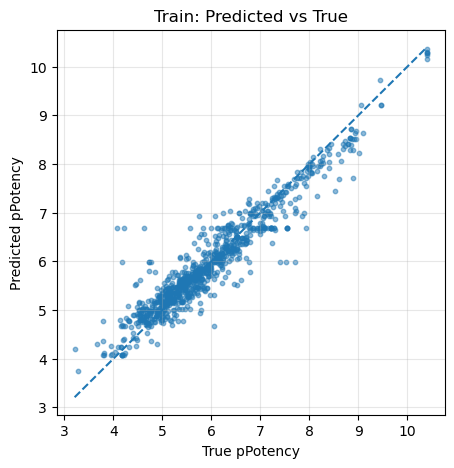

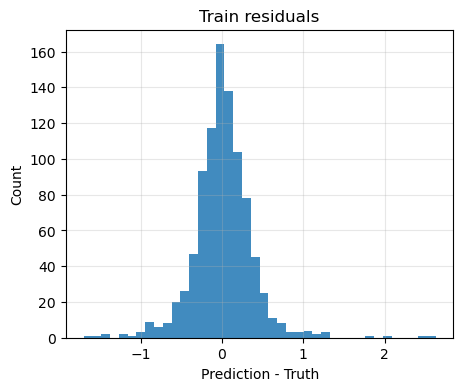

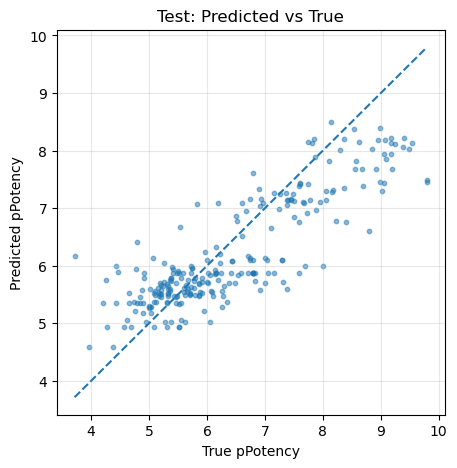

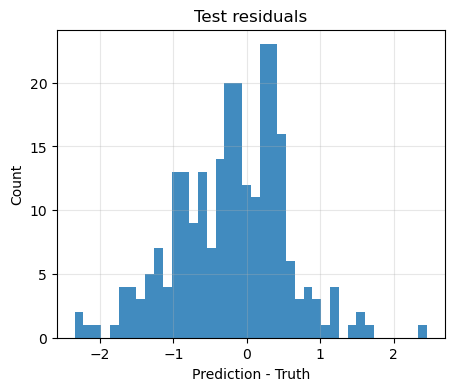


[Activity @ ≤1.0 µM] ROC/PR
Train ROC-AUC: 0.989 PR-AUC: 0.981
Test  ROC-AUC: 0.902 PR-AUC: 0.908

Classification report (Test):
              precision    recall  f1-score   support

           0      0.765     0.938     0.843       160
           1      0.913     0.695     0.789       151

    accuracy                          0.820       311
   macro avg      0.839     0.816     0.816       311
weighted avg      0.837     0.820     0.817       311



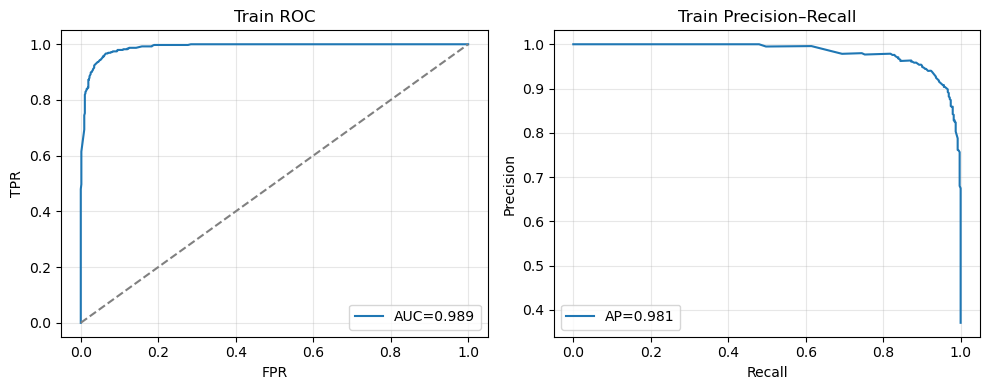

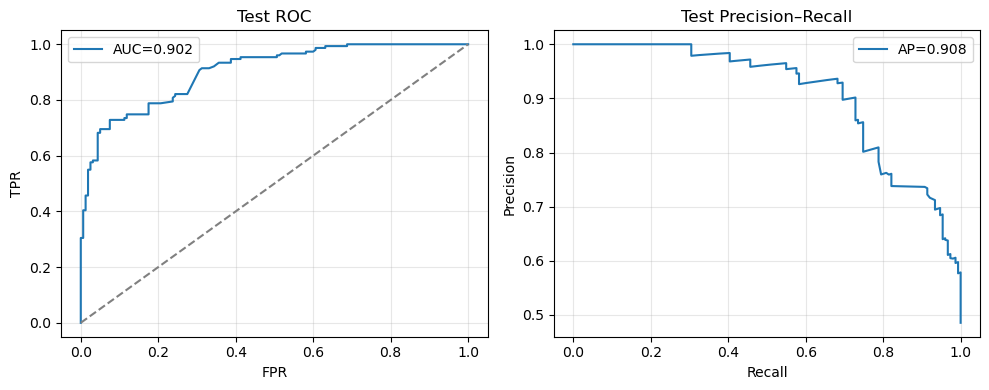

/users/sghosh6/.conda/envs/pubchemData/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/users/sghosh6/.conda/envs/pubchemData/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-lear


[Virus classifier on actives]
Held-out accuracy: 0.887
Classes: ['Ebola', 'Lassa', 'Marburg', 'VEEV']

Classification report (Test):
              precision    recall  f1-score   support

       Ebola      1.000     0.789     0.882        71
       Lassa      0.985     1.000     0.993        67
     Marburg      0.111     1.000     0.200         2
        VEEV      1.000     0.800     0.889        10

    accuracy                          0.887       150
   macro avg      0.774     0.897     0.741       150
weighted avg      0.982     0.887     0.923       150



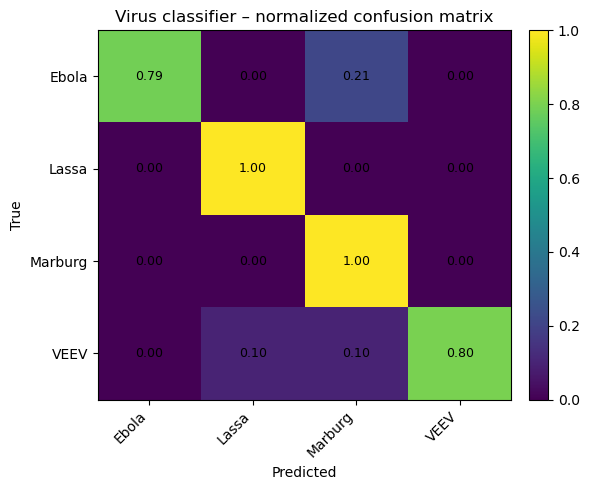

In [61]:
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report
)
from sklearn.preprocessing import LabelEncoder
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------
# Configuration
# ---------------------------
df = allVirusData_chEMBL_uM_wRDKit.copy()

ACTIVITY_THRESHOLD_UM = 1.0     # "active" if value_uM <= threshold (try 1.0–10.0)
USE_VIRUS_CLASSIFIER = True     # set False to skip virus classifier
RANDOM_STATE = 42

# ---------------------------
# Sanity checks (fail fast)
# ---------------------------
needed_cols = {
    "smiles","pPotency","value_uM","Virus","invalidSmiles",
    "molecular_weight","AlogP","polar_surface_area","hba","hbd",
    "rotatable_bonds","qed_weighted","heavy_atoms","aromatic_rings","ro5_violations"
}
missing = [c for c in needed_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

# Ensure numeric physchem
phys_cols = [
    "molecular_weight","AlogP","polar_surface_area","hba","hbd",
    "rotatable_bonds","qed_weighted","heavy_atoms","aromatic_rings","ro5_violations"
]
df[phys_cols] = df[phys_cols].apply(pd.to_numeric, errors="coerce")

# Keep rows with usable SMILES and fingerprints
df = df[df["smiles"].notna() & (~df["invalidSmiles"].fillna(True))].copy()

# Labels
df["isExactPotency"] = df["pPotency"].notna()
df["isActive"] = (pd.to_numeric(df["value_uM"], errors="coerce") <= ACTIVITY_THRESHOLD_UM)

print(f"Rows total:                 {len(df)}")
print(f"Rows with exact pPotency:   {int(df['isExactPotency'].sum())}")
print(f"Rows active @ ≤{ACTIVITY_THRESHOLD_UM} µM: {int(df['isActive'].sum())}")

# ---------------------------
# Features
# ---------------------------
# ECFP + MACCS columns by prefix (generated earlier)
ecfp_cols  = [c for c in df.columns if c.startswith("ecfpR2_2048_b")]
maccs_cols = [c for c in df.columns if c.startswith("maccs_b")]
if not ecfp_cols:
    raise ValueError("No ECFP columns found (expected prefix 'ecfpR2_2048_b').")
if not maccs_cols:
    raise ValueError("No MACCS columns found (expected prefix 'maccs_b').")

X_cols = ecfp_cols + maccs_cols + phys_cols
X_all = df[X_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy()

# ---------------------------
# Scaffold split (chemotype-aware)
# ---------------------------
def smiles_to_scaffold(smi: str) -> str:
    try:
        m = Chem.MolFromSmiles(smi)
        if m is None:
            return ""
        core = MurckoScaffold.GetScaffoldForMol(m)
        return Chem.MolToSmiles(core) if core is not None else ""
    except Exception:
        return ""

df["scaffold"] = df["smiles"].astype(str).apply(smiles_to_scaffold)

rng = np.random.RandomState(RANDOM_STATE)
scaffolds = pd.Series(df["scaffold"].fillna("").unique())
rng.shuffle(scaffolds.values)
cut = int(0.8 * len(scaffolds))
train_scaffolds = set(scaffolds.iloc[:cut])
test_scaffolds  = set(scaffolds.iloc[cut:])

train_idx = df["scaffold"].isin(train_scaffolds).to_numpy()
test_idx  = df["scaffold"].isin(test_scaffolds).to_numpy()

# ---------------------------
# Regression: pPotency
# ---------------------------
reg_mask_tr = train_idx & df["isExactPotency"].to_numpy()
reg_mask_te = test_idx  & df["isExactPotency"].to_numpy()

X_tr_reg = X_all[reg_mask_tr]
y_tr_reg = df.loc[reg_mask_tr, "pPotency"].to_numpy()

X_te_reg = X_all[reg_mask_te]
y_te_reg = df.loc[reg_mask_te, "pPotency"].to_numpy()

reg_model = RandomForestRegressor(
    n_estimators=600,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE
)
reg_model.fit(X_tr_reg, y_tr_reg)

y_pred_tr = reg_model.predict(X_tr_reg)
y_pred_te = reg_model.predict(X_te_reg)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def summarize_reg(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    print(f"\n[{label}] pPotency regression")
    print(f"R2   : {r2_score(y_true, y_pred):.4f}")
    print(f"RMSE : {rmse(y_true, y_pred):.4f}")
    print(f"MAE  : {mean_absolute_error(y_true, y_pred):.4f}")

summarize_reg(y_tr_reg, y_pred_tr, "Train")
summarize_reg(y_te_reg, y_pred_te, "Test")

# Plots: pred vs true + residuals
def plot_pred_vs_true(y_true, y_pred, title):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    fig, ax = plt.subplots(figsize=(5,5))
    ax.scatter(y_true, y_pred, s=10, alpha=0.5)
    mn = float(np.nanmin([y_true.min(), y_pred.min()]))
    mx = float(np.nanmax([y_true.max(), y_pred.max()]))
    ax.plot([mn, mx], [mn, mx], '--')
    ax.set_xlabel("True pPotency")
    ax.set_ylabel("Predicted pPotency")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.show()

def plot_residuals(y_true, y_pred, title):
    resid = np.asarray(y_pred) - np.asarray(y_true)
    fig, ax = plt.subplots(figsize=(5,4))
    ax.hist(resid, bins=40, alpha=0.85)
    ax.set_title(f"{title} residuals")
    ax.set_xlabel("Prediction - Truth")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)
    plt.show()

plot_pred_vs_true(y_tr_reg, y_pred_tr, "Train: Predicted vs True")
plot_residuals(y_tr_reg, y_pred_tr, "Train")
plot_pred_vs_true(y_te_reg, y_pred_te, "Test: Predicted vs True")
plot_residuals(y_te_reg, y_pred_te, "Test")

# ---------------------------
# Binary activity classifier (active ≤ threshold µM)
# ---------------------------
cls_mask_tr = train_idx & df["value_uM"].notna().to_numpy()
cls_mask_te = test_idx  & df["value_uM"].notna().to_numpy()

X_tr_cls = X_all[cls_mask_tr]
y_tr_cls = df.loc[cls_mask_tr, "isActive"].astype(int).to_numpy()
X_te_cls = X_all[cls_mask_te]
y_te_cls = df.loc[cls_mask_te, "isActive"].astype(int).to_numpy()

cls_model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    solver="liblinear",
    max_iter=300,
    random_state=RANDOM_STATE
)
cls_model.fit(X_tr_cls, y_tr_cls)

proba_tr = cls_model.predict_proba(X_tr_cls)[:, 1]
proba_te = cls_model.predict_proba(X_te_cls)[:, 1]
pred_tr = (proba_tr >= 0.5).astype(int)
pred_te = (proba_te >= 0.5).astype(int)

def plot_roc_pr(y_true, y_score, split_label):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc  = average_precision_score(y_true, y_score)

    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    axes[0].plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    axes[0].plot([0,1],[0,1],'--', color='gray')
    axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
    axes[0].set_title(f"{split_label} ROC"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(rec, prec, label=f"AP={pr_auc:.3f}")
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{split_label} Precision–Recall"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

print(f"\n[Activity @ ≤{ACTIVITY_THRESHOLD_UM} µM] ROC/PR")
print("Train ROC-AUC:", f"{roc_auc_score(y_tr_cls, proba_tr):.3f}",
      "PR-AUC:", f"{average_precision_score(y_tr_cls, proba_tr):.3f}")
print("Test  ROC-AUC:", f"{roc_auc_score(y_te_cls, proba_te):.3f}",
      "PR-AUC:", f"{average_precision_score(y_te_cls, proba_te):.3f}")

print("\nClassification report (Test):")
print(classification_report(y_te_cls, pred_te, digits=3))

plot_roc_pr(y_tr_cls, proba_tr, "Train")
plot_roc_pr(y_te_cls, proba_te, "Test")

# ---------------------------
# Virus classifier (multiclass, on active compounds only)
# ---------------------------
active_mask = df["isActive"].to_numpy()
tr_mask = train_idx & active_mask
te_mask = test_idx  & active_mask

# Keep only virus classes with adequate support in train
min_train_per_class = 10
train_counts = df.loc[tr_mask, "Virus"].value_counts()
keep_labels = train_counts[train_counts >= min_train_per_class].index

tr_mask = tr_mask & df["Virus"].isin(keep_labels).to_numpy()
te_mask = te_mask & df["Virus"].isin(keep_labels).to_numpy()

X_tr_v = X_all[tr_mask]
X_te_v = X_all[te_mask]

y_tr_v_raw = df.loc[tr_mask, "Virus"].astype(str).values
y_te_v_raw = df.loc[te_mask, "Virus"].astype(str).values

if len(np.unique(y_tr_v_raw)) >= 2 and len(y_te_v_raw) > 0:
    # Label encode targets for sklearn
    le = LabelEncoder()
    y_tr_v = le.fit_transform(y_tr_v_raw)
    y_te_v = le.transform(y_te_v_raw)

    # One-vs-Rest logistic regression (multinomial-friendly, no deprecation)
    virus_clf = OneVsRestClassifier(
        LogisticRegression(
            solver="lbfgs",        # multinomial-capable, stable on dense features
            penalty="l2",
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
    virus_clf.fit(X_tr_v, y_tr_v)

    y_pred_v = virus_clf.predict(X_te_v)
    acc = (y_pred_v == y_te_v).mean()

    print("\n[Virus classifier on actives]")
    print("Held-out accuracy:", f"{acc:.3f}")
    print("Classes:", list(le.classes_))
    print("\nClassification report (Test):")
    print(classification_report(y_te_v, y_pred_v, target_names=le.classes_, digits=3))

    # Confusion matrix (normalized by true class)
    cm = confusion_matrix(y_te_v, y_pred_v, labels=np.arange(len(le.classes_)), normalize="true")
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation="nearest", aspect="auto")
    ax.set_title("Virus classifier – normalized confusion matrix")
    ax.set_xticks(np.arange(len(le.classes_)))
    ax.set_xticklabels(le.classes_, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(le.classes_)))
    ax.set_yticklabels(le.classes_)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout(); plt.show()
else:
    print("\n[Virus classifier] Skipped (insufficient active data per class).")


# Prepare data for ML model for all strains of EBola virus

In [124]:
EbolaAllStrainsData_chEMBL = pd.read_csv(modelBuildingDataDir + 'EbolaData_chEMBL_combined_allStrains.csv')
EbolaAllStrainsData_chEMBL

,strain,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,hba,hbd,rotatable_bonds,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism
0,Ebola,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...,602.59,Small molecule,80000.0,/ml,...,13.0,4.0,13.0,0.16,42.0,3.0,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus
1,Ebola,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...,602.59,Small molecule,NaN,NaN,...,13.0,4.0,13.0,0.16,42.0,3.0,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus
2,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.27,Small molecule,100000.0,nM,...,8.0,2.0,6.0,0.70,19.0,2.0,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus
3,Ebola,CHEMBL4080961,Nc1nccc2c1ncn2[C@H]1C=C[C@H](O)[C@@H]1O,C11H12N4O2,UJJIREDPTVPNLW-OYNCUSHFSA-N,InChI=1S/C11H12N4O2/c12-11-9-6(3-4-13-11)15(5-...,232.24,Small molecule,29.5,ug.mL-1,...,6.0,3.0,1.0,0.59,17.0,2.0,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus
4,Ebola,CHEMBL4081268,Nc1ncc(Br)c2c1ncn2[C@@H]1[C@@H](O)[C@@H](O)[C@...,C12H13BrN4O2,XJUUPHWULCINAO-MZFBDAEWSA-N,InChI=1S/C12H13BrN4O2/c13-6-2-15-12(14)7-9(6)1...,325.17,Small molecule,NaN,NaN,...,6.0,3.0,1.0,0.72,19.0,2.0,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1420,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,nM,...,4.0,2.0,9.0,0.34,34.0,4.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus
1421,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,nM,...,4.0,2.0,9.0,0.34,34.0,4.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus
1422,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,nM,...,4.0,2.0,10.0,0.35,33.0,3.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus
1423,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,nM,...,4.0,2.0,10.0,0.35,33.0,3.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus


### Count Standard Type

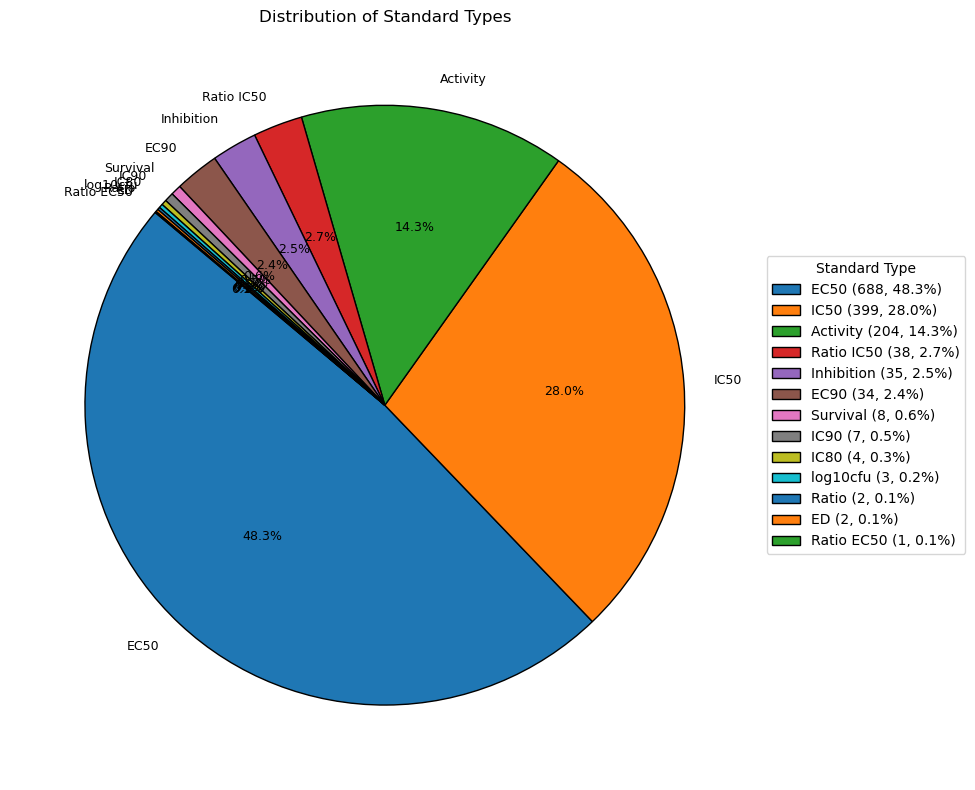

In [125]:
# Count occurrences of each Standard Type
type_counts = EbolaAllStrainsData_chEMBL["standard_type"].value_counts()
total = type_counts.sum()

# Legend labels with counts and percentages
legend_labels = [
    f"{stype} ({count}, {count/total:.1%})"
    for stype, count in type_counts.items()
]

# Plot pie chart with inside labels showing just Standard Type
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    type_counts,
    labels=type_counts.index,  # short labels inside slices
    autopct='%1.1f%%',         # show % inside too
    startangle=140,
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontsize': 9}
)

# Legend with full details
plt.legend(
    wedges,
    legend_labels,
    title="Standard Type",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title("Distribution of Standard Types")
plt.tight_layout()
plt.show()

In [126]:
# Count and sort standard_type values
typeCounts = EbolaAllStrainsData_chEMBL["standard_type"].value_counts(dropna=True)
total = typeCounts.sum()

print("Standard Types sorted by frequency:\n")
for stype, count in typeCounts.items():
    pct = (count / total) * 100
    print(f"{stype:30s} : {count:6d}  ({pct:5.2f}%)")

Standard Types sorted by frequency:

EC50                           :    688  (48.28%)
IC50                           :    399  (28.00%)
Activity                       :    204  (14.32%)
Ratio IC50                     :     38  ( 2.67%)
Inhibition                     :     35  ( 2.46%)
EC90                           :     34  ( 2.39%)
Survival                       :      8  ( 0.56%)
IC90                           :      7  ( 0.49%)
IC80                           :      4  ( 0.28%)
log10cfu                       :      3  ( 0.21%)
Ratio                          :      2  ( 0.14%)
ED                             :      2  ( 0.14%)
Ratio EC50                     :      1  ( 0.07%)


### Understanding Standard Types in Bioactivity Data

In antiviral drug design, **Standard Types** represent the biological readouts measured in assays.  
They indicate how effective and safe a compound is against a virus:

- **IC50 / IC90 / IC80** → Concentration that inhibits 50%, 90%, or 80% of viral activity (potency).  
- **EC50 / EC90** → Concentration that achieves 50% or 90% of the desired effect in cells (cell-based efficacy).  
- **ED50 / ED** → Dose at which 50% of test animals show the desired effect (in vivo efficacy).  
- **Activity / Inhibition** → General measures of viral suppression or % inhibition at fixed dose.  
- **Selectivity Index (SI)** → Safety margin = toxic dose / effective dose.  
- **Survival** → % survival in treated vs untreated groups (animal/clinical studies).  
- **Fold Change (FC), Ratio IC50/EC50** → Resistance or comparative potency metrics.  
- **Log(activity), log10CFU** → Log-scaled activity or viral load measures.  

In short: 
- For early drug discovery: IC50/EC50 are the most critical.
- For translation to animals/clinics: ED50, Selectivity Index, and Survival become essential.
- For resistance studies: Ratio IC50/EC50 matters.

### Converts all standard types (IC50/EC50/IC90/EC90) to µM

In [127]:
# 1) Which standard types are convertible?
# Convertible (by definition concentration endpoints): ICxx / ECxx (e.g., IC50, EC90, IC80, EC99, etc.)
# Also convertible if present: Ki, Kd (binding constants—concentrations)
CONC_TYPE_PATTERNS = [
    r'\b[IE]C\s*\d+\b',   # IC50, EC90, etc. (spaces tolerated)
    r'\bK[di]\b',         # Ki or Kd
]

# Units we can convert to µM
UNIT_TO_uM = {
    "M": 1e6,
    "mM": 1e3,
    "uM": 1.0, "μM": 1.0, "µM": 1.0,
    "nM": 1e-3,
    "pM": 1e-6,
}

def is_conc_type(std_type: str) -> bool:
    if not isinstance(std_type, str):
        return False
    s = std_type.strip()
    s_no_space = s.replace(" ", "")
    return any(re.search(pat, s_no_space, flags=re.IGNORECASE) for pat in CONC_TYPE_PATTERNS)

def to_uM(value, unit):
    if pd.isna(value) or pd.isna(unit):
        return np.nan
    factor = UNIT_TO_uM.get(str(unit).strip())
    if factor is None:
        return np.nan
    try:
        return float(value) * factor
    except Exception:
        return np.nan

# 2) Copy the original DataFrame
EbolaAllStrainsData_chEMBL_uM = EbolaAllStrainsData_chEMBL.copy()   

# 3) Add conversion flags and the µM column
EbolaAllStrainsData_chEMBL_uM["is_conc_type"] = EbolaAllStrainsData_chEMBL_uM["standard_type"].apply(is_conc_type)
EbolaAllStrainsData_chEMBL_uM["has_known_unit"] = EbolaAllStrainsData_chEMBL_uM["standard_units"].isin(UNIT_TO_uM.keys())
EbolaAllStrainsData_chEMBL_uM["is_numeric_value"] = pd.to_numeric(EbolaAllStrainsData_chEMBL_uM["standard_value"], errors="coerce").notna()

# Convertible if: concentration-type AND known unit AND numeric value
EbolaAllStrainsData_chEMBL_uM["is_convertible_to_uM"] = (
    EbolaAllStrainsData_chEMBL_uM["is_conc_type"] &
    EbolaAllStrainsData_chEMBL_uM["has_known_unit"] &
    EbolaAllStrainsData_chEMBL_uM["is_numeric_value"]
)

# Compute µM values where convertible; else NaN
EbolaAllStrainsData_chEMBL_uM["value_uM"] = np.where(
    EbolaAllStrainsData_chEMBL_uM["is_convertible_to_uM"],
    [to_uM(v, u) for v, u in zip(EbolaAllStrainsData_chEMBL_uM["standard_value"], EbolaAllStrainsData_chEMBL_uM["standard_units"])],
    np.nan
)

# Quick summary
print("Convertible standards:", int(EbolaAllStrainsData_chEMBL_uM["is_convertible_to_uM"].sum()))
print("Non-convertible standards:", int((~EbolaAllStrainsData_chEMBL_uM["is_convertible_to_uM"]).sum()))

columns_to_drop = [
        'is_conc_type', 
        'has_known_unit', 
        'is_numeric_value', 
        'is_convertible_to_uM'
    ]
    
# Drop the columns, using errors='ignore' to avoid a KeyError if a column doesn't exist
EbolaAllStrainsData_chEMBL_uM = EbolaAllStrainsData_chEMBL_uM.drop(columns=columns_to_drop, errors='ignore')
EbolaAllStrainsData_chEMBL_uM

Convertible standards: 1112
Non-convertible standards: 313


,strain,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,hbd,rotatable_bonds,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,value_uM
0,Ebola,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...,602.59,Small molecule,80000.0,/ml,...,4.0,13.0,0.16,42.0,3.0,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus,NaN
1,Ebola,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...,602.59,Small molecule,NaN,NaN,...,4.0,13.0,0.16,42.0,3.0,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus,NaN
2,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.27,Small molecule,100000.0,nM,...,2.0,6.0,0.70,19.0,2.0,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,100.00
3,Ebola,CHEMBL4080961,Nc1nccc2c1ncn2[C@H]1C=C[C@H](O)[C@@H]1O,C11H12N4O2,UJJIREDPTVPNLW-OYNCUSHFSA-N,InChI=1S/C11H12N4O2/c12-11-9-6(3-4-13-11)15(5-...,232.24,Small molecule,29.5,ug.mL-1,...,3.0,1.0,0.59,17.0,2.0,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,NaN
4,Ebola,CHEMBL4081268,Nc1ncc(Br)c2c1ncn2[C@@H]1[C@@H](O)[C@@H](O)[C@...,C12H13BrN4O2,XJUUPHWULCINAO-MZFBDAEWSA-N,InChI=1S/C12H13BrN4O2/c13-6-2-15-12(14)7-9(6)1...,325.17,Small molecule,NaN,NaN,...,3.0,1.0,0.72,19.0,2.0,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1420,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,nM,...,2.0,9.0,0.34,34.0,4.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.52
1421,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,nM,...,2.0,9.0,0.34,34.0,4.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.52
1422,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,nM,...,2.0,10.0,0.35,33.0,3.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.90
1423,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,nM,...,2.0,10.0,0.35,33.0,3.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.90


### Keep only those rows which have Convertible standards

In [128]:
EbolaAllStrainsData_chEMBL_uM = EbolaAllStrainsData_chEMBL_uM.dropna(subset=['value_uM'])
EbolaAllStrainsData_chEMBL_uM

,strain,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,hbd,rotatable_bonds,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,value_uM
2,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.27,Small molecule,100000.0,nM,...,2.0,6.0,0.70,19.0,2.0,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,100.00
5,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,C12H14N4O3,PCJCKCSFBICBNZ-NRZXQICZSA-N,InChI=1S/C12H14N4O3/c13-12-9-7(1-2-14-12)16(5-...,262.27,Small molecule,320.0,nM,...,4.0,2.0,0.56,19.0,2.0,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,0.32
6,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C37H42N3O5P,BCNOLUKYPQLFDY-UHFFFAOYSA-N,"InChI=1S/C37H42N3O5P/c1-3-43-46(41,44-4-2)27-3...",639.73,Unknown,1880.0,nM,...,1.0,14.0,0.12,46.0,5.0,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus,1.88
7,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C38H41F3N3O5P,YPONQFDDBHJAOJ-UHFFFAOYSA-N,"InChI=1S/C38H41F3N3O5P/c1-3-47-50(45,48-4-2)26...",707.73,Unknown,2490.0,nM,...,1.0,14.0,0.12,50.0,5.0,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus,2.49
8,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,C43H65N6O9P,VXYCOVDOXKSLFC-NKSQPNMBSA-N,InChI=1S/C43H65N6O9P/c1-5-8-9-10-11-12-13-14-1...,841.00,Unknown,50000.0,nM,...,3.0,28.0,0.04,59.0,3.0,3.0,CHEMBL4434621,Ebolavirus,Ebolavirus,50.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1420,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,nM,...,2.0,9.0,0.34,34.0,4.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.52
1421,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,nM,...,2.0,9.0,0.34,34.0,4.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.52
1422,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,nM,...,2.0,10.0,0.35,33.0,3.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.90
1423,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,nM,...,2.0,10.0,0.35,33.0,3.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.90


### Add p-scale (pPotency) conversion to bring all concentrations (µM) onto a logarithmic scale

In [129]:
dfp = EbolaAllStrainsData_chEMBL_uM.copy()  # your frame with `value_uM`

# 1) Make sure value_uM is numeric
dfp["value_uM"] = pd.to_numeric(dfp.get("value_uM"), errors="coerce")

# 2) Normalize the relation column (handles "'", spaces, synonyms, unicode)
def normalize_relation(rel):
    if pd.isna(rel):
        return None
    s = str(rel).strip()

    # remove surrounding quotes if present
    if (s.startswith("'") and s.endswith("'")) or (s.startswith('"') and s.endswith('"')):
        s = s[1:-1].strip()

    s = s.strip().lower()

    # map HTML/unicode and synonyms
    s = s.replace("&lt;", "<").replace("&gt;", ">")
    s = s.replace("≤", "<=").replace("≥", ">=")
    s = s.replace("==", "=")

    # word synonyms
    if s in {"eq", "equals", "equal"}:
        s = "="
    elif s in {"lt", "less", "lessthan"}:
        s = "<"
    elif s in {"le", "lessequal", "lessthanorequal"}:
        s = "<="
    elif s in {"gt", "greater", "greaterthan"}:
        s = ">"
    elif s in {"ge", "greaterequal", "greaterthanorequal"}:
        s = ">="
    elif s in {"approx", "~", "≈"}:
        s = "="

    # keep only one of: =, <, >, <=, >= ; else None
    if s in {"=", "<", ">", "<=", ">="}:
        return s
    return None

dfp["relation_norm"] = dfp.get("standard_relation").apply(normalize_relation)

# 3) Safe log10
def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = x > 0
    out[mask] = np.log10(x[mask])
    return out

# 4) Compute pPotency (p = 6 - log10(µM))
p_from_uM = 6.0 - safe_log10(dfp["value_uM"])

# exact if relation is '=' or missing
has_exact = (dfp["relation_norm"].isna()) | (dfp["relation_norm"].eq('='))

# lower/upper bounds for censored values
is_lt  = dfp["relation_norm"].eq('<')
is_le  = dfp["relation_norm"].eq('<=')
is_gt  = dfp["relation_norm"].eq('>')
is_ge  = dfp["relation_norm"].eq('>=')

dfp["pPotency"]       = np.where(has_exact, p_from_uM, np.nan)
dfp["pPotencyLower"]  = np.where(is_lt | is_le, p_from_uM, np.nan)  # true conc < / ≤ value → pPotency > bound
dfp["pPotencyUpper"]  = np.where(is_gt | is_ge, p_from_uM, np.nan)  # true conc > / ≥ value → pPotency < bound
dfp["pPotencyMid"]    = dfp[["pPotency", "pPotencyLower", "pPotencyUpper"]].median(axis=1, skipna=True)

# 5) Summary
n_exact = int(dfp["pPotency"].notna().sum())
n_lower = int(dfp["pPotencyLower"].notna().sum())
n_upper = int(dfp["pPotencyUpper"].notna().sum())
print(f"Exact pPotency rows: {n_exact}")
print(f"Censored lower-bound rows (relation '<' or '<='): {n_lower}")
print(f"Censored upper-bound rows (relation '>' or '>='): {n_upper}")

# Replace the working frame if you want
EbolaAllStrainsData_chEMBL_uM = dfp
EbolaAllStrainsData_chEMBL_uM

Exact pPotency rows: 1017
Censored lower-bound rows (relation '<' or '<='): 11
Censored upper-bound rows (relation '>' or '>='): 84


,strain,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,value_uM,relation_norm,pPotency,pPotencyLower,pPotencyUpper,pPotencyMid
2,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.27,Small molecule,100000.0,nM,...,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,100.00,>,NaN,NaN,4.00000,4.000000
5,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,C12H14N4O3,PCJCKCSFBICBNZ-NRZXQICZSA-N,InChI=1S/C12H14N4O3/c13-12-9-7(1-2-14-12)16(5-...,262.27,Small molecule,320.0,nM,...,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,0.32,<,NaN,6.49485,NaN,6.494850
6,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C37H42N3O5P,BCNOLUKYPQLFDY-UHFFFAOYSA-N,"InChI=1S/C37H42N3O5P/c1-3-43-46(41,44-4-2)27-3...",639.73,Unknown,1880.0,nM,...,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus,1.88,=,5.725842,NaN,NaN,5.725842
7,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C38H41F3N3O5P,YPONQFDDBHJAOJ-UHFFFAOYSA-N,"InChI=1S/C38H41F3N3O5P/c1-3-47-50(45,48-4-2)26...",707.73,Unknown,2490.0,nM,...,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus,2.49,=,5.603801,NaN,NaN,5.603801
8,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,C43H65N6O9P,VXYCOVDOXKSLFC-NKSQPNMBSA-N,InChI=1S/C43H65N6O9P/c1-5-8-9-10-11-12-13-14-1...,841.00,Unknown,50000.0,nM,...,3.0,CHEMBL4434621,Ebolavirus,Ebolavirus,50.00,>,NaN,NaN,4.30103,4.301030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1420,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,nM,...,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.52,=,6.283997,NaN,NaN,6.283997
1421,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,nM,...,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.52,=,6.283997,NaN,NaN,6.283997
1422,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,nM,...,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.90,=,5.721246,NaN,NaN,5.721246
1423,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,nM,...,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.90,=,5.721246,NaN,NaN,5.721246


### some data cleaning

In [130]:
len(EbolaAllStrainsData_chEMBL_uM.dropna(subset=['pPotencyLower']))

11

In [131]:
len(EbolaAllStrainsData_chEMBL_uM.dropna(subset=['pPotencyUpper']))

84

In [132]:
len(EbolaAllStrainsData_chEMBL_uM.dropna(subset=['pPotency']))

1017

In [133]:
len(EbolaAllStrainsData_chEMBL_uM.dropna(subset=['pPotencyMid']))

1112

In [134]:
EbolaAllStrainsData_chEMBL_uM = EbolaAllStrainsData_chEMBL_uM.drop(columns=['relation_norm','pPotencyLower', 'pPotencyUpper'], errors='ignore')
EbolaAllStrainsData_chEMBL_uM

,strain,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,value_uM,pPotency,pPotencyMid
2,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.27,Small molecule,100000.0,nM,...,0.70,19.0,2.0,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,100.00,NaN,4.000000
5,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,C12H14N4O3,PCJCKCSFBICBNZ-NRZXQICZSA-N,InChI=1S/C12H14N4O3/c13-12-9-7(1-2-14-12)16(5-...,262.27,Small molecule,320.0,nM,...,0.56,19.0,2.0,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,0.32,NaN,6.494850
6,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C37H42N3O5P,BCNOLUKYPQLFDY-UHFFFAOYSA-N,"InChI=1S/C37H42N3O5P/c1-3-43-46(41,44-4-2)27-3...",639.73,Unknown,1880.0,nM,...,0.12,46.0,5.0,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus,1.88,5.725842,5.725842
7,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C38H41F3N3O5P,YPONQFDDBHJAOJ-UHFFFAOYSA-N,"InChI=1S/C38H41F3N3O5P/c1-3-47-50(45,48-4-2)26...",707.73,Unknown,2490.0,nM,...,0.12,50.0,5.0,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus,2.49,5.603801,5.603801
8,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,C43H65N6O9P,VXYCOVDOXKSLFC-NKSQPNMBSA-N,InChI=1S/C43H65N6O9P/c1-5-8-9-10-11-12-13-14-1...,841.00,Unknown,50000.0,nM,...,0.04,59.0,3.0,3.0,CHEMBL4434621,Ebolavirus,Ebolavirus,50.00,NaN,4.301030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1420,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,nM,...,0.34,34.0,4.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.52,6.283997,6.283997
1421,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,nM,...,0.34,34.0,4.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.52,6.283997,6.283997
1422,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,nM,...,0.35,33.0,3.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.90,5.721246,5.721246
1423,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,nM,...,0.35,33.0,3.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.90,5.721246,5.721246


In [135]:
EbolaAllStrainsData_chEMBL_uM.to_csv(os.path.join(modelBuildingDataDir, "EbolaAllStrainsData_chEMBL_uM.csv"))